# Classification and Evaluation in NLP

**Text classification** is a common Natural Language Processing (NLP) task where a model assigns a predefined category or label to a piece of text.

Examples include:
- Spam detection
- Sentiment analysis
- News categorization

In this lab, we will learn how to build and evaluate a text classification model.

## Case Study: Sentiment Analysis

Sentiment analysis, also known as opinion mining, its goal is to understand the information present in the text and categorize it as positive, negative, or neutral.

### Student Name: Abbas Abdulaziz Al Thunayan
### Student ID: 2240004112


Run all cells from top to bottom. The first run needs internet to install missing libraries and download both datasets. Downloaded CSV files are reused on later runs.


In [1]:
import importlib.util
import subprocess
import sys
from pathlib import Path
from urllib.request import urlopen
from zipfile import ZipFile
from io import BytesIO

for module, package in [('pandas', 'pandas'), ('sklearn', 'scikit-learn'), ('matplotlib', 'matplotlib')]:
    if importlib.util.find_spec(module) is None:
        print(f'Installing {package} ...', flush=True)
        result = subprocess.run(
            [sys.executable, '-m', 'pip', 'install', package],
            capture_output=True, text=True, timeout=180
        )
        print(result.stdout)
        if result.returncode != 0:
            raise RuntimeError(result.stderr)
print('Libraries are ready.')

def download_csv(dataset, filename):
    path = Path(filename)
    if not path.exists():
        print(f'Downloading {filename} ...', flush=True)
        url = 'https://www.kaggle.com/api/v1/datasets/download/' + dataset
        with urlopen(url, timeout=120) as response:
            archive_bytes = response.read()
        with ZipFile(BytesIO(archive_bytes)) as archive:
            member = next(name for name in archive.namelist() if Path(name).name == filename)
            path.write_bytes(archive.read(member))
    return path


Libraries are ready.


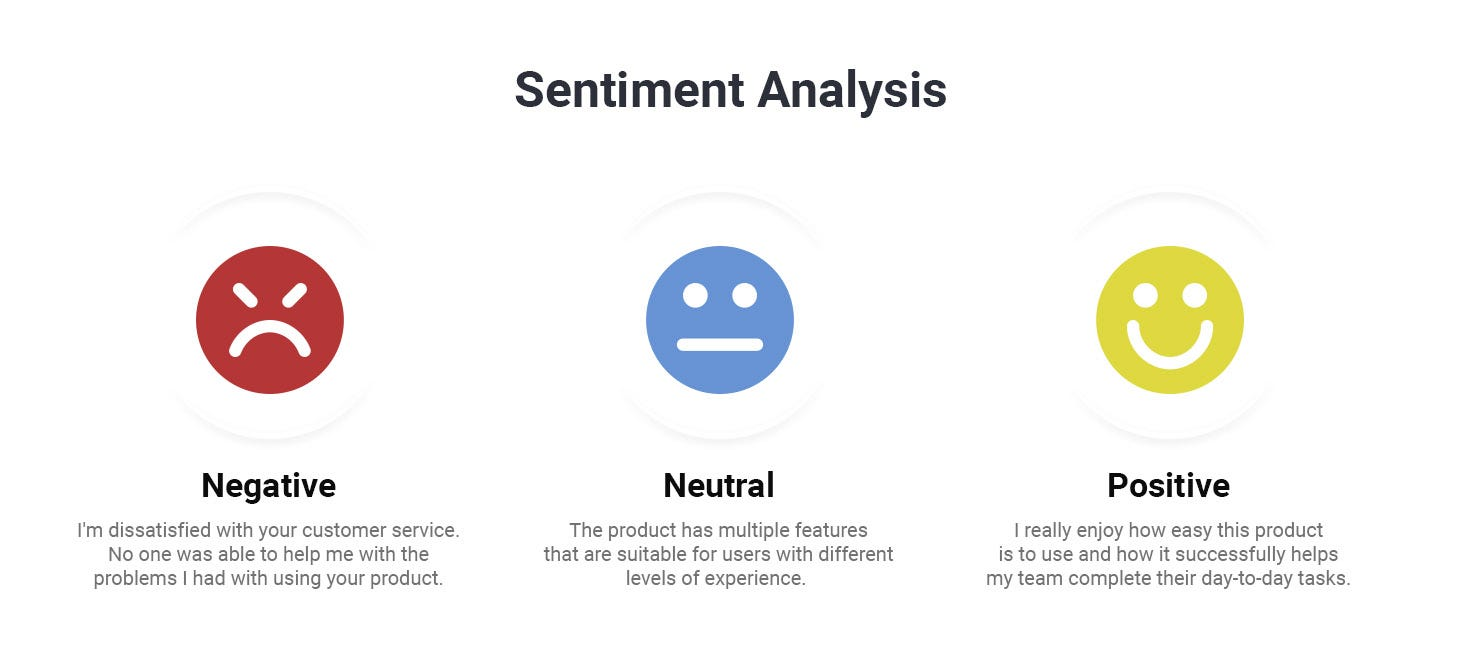

# Disneyland Reviews Dataset
In this lab we'll look into Disneyland Reviews dataset.  
*Link: https://www.kaggle.com/datasets/arushchillar/disneyland-reviews*

The dataset includes 42,000 reviews of 3 Disneyland branches - Paris, California and Hong Kong, posted by visitors on Trip Advisor.

Column Description:

- Review_ID: unique id given to each review
- Rating: ranging from 1 (unsatisfied) to 5 (satisfied)
- Year_Month: when the reviewer visited the theme park
- Reviewer_Location: country of origin of visitor
- Review_Text: comments made by visitor
- Disneyland_Branch: location of Disneyland Park

In [2]:
# Download once, then reuse the local CSV.
import pandas as pd

file_path = download_csv('arushchillar/disneyland-reviews', 'DisneylandReviews.csv')
data = pd.read_csv(file_path, encoding='latin-1')
print('Dataset shape:', data.shape)
data.head()


Dataset shape: (42656, 6)


,Review_ID,Rating,Year_Month,Reviewer_Location,Review_Text,Branch
0,670772142,4,2019-4,Australia,If you've ever been to Disneyland anywhere you...,Disneyland_HongKong
1,670682799,4,2019-5,Philippines,Its been a while since d last time we visit HK...,Disneyland_HongKong
2,670623270,4,2019-4,United Arab Emirates,Thanks God it wasn t too hot or too humid wh...,Disneyland_HongKong
3,670607911,4,2019-4,Australia,HK Disneyland is a great compact park. Unfortu...,Disneyland_HongKong
4,670607296,4,2019-4,United Kingdom,"the location is not in the city, took around 1...",Disneyland_HongKong


In [3]:
#Check for missing values
data.isna().sum()

Review_ID            0
Rating               0
Year_Month           0
Reviewer_Location    0
Review_Text          0
Branch               0
dtype: int64

In [4]:
data = data.dropna(subset=['Review_Text', 'Rating']).copy()


In [5]:
# Map star ratings to sentiments
data['Sentiment'] = data['Rating'].apply(lambda rating: 'positive' if rating > 3 else ('negative' if rating < 3 else 'neutral'))
data.head()

,Review_ID,Rating,Year_Month,Reviewer_Location,Review_Text,Branch,Sentiment
0,670772142,4,2019-4,Australia,If you've ever been to Disneyland anywhere you...,Disneyland_HongKong,positive
1,670682799,4,2019-5,Philippines,Its been a while since d last time we visit HK...,Disneyland_HongKong,positive
2,670623270,4,2019-4,United Arab Emirates,Thanks God it wasn t too hot or too humid wh...,Disneyland_HongKong,positive
3,670607911,4,2019-4,Australia,HK Disneyland is a great compact park. Unfortu...,Disneyland_HongKong,positive
4,670607296,4,2019-4,United Kingdom,"the location is not in the city, took around 1...",Disneyland_HongKong,positive


In [6]:
import re

def preprocess_text(text):
    text = str(text).lower()
    text = re.sub(r"n['’]t\b", ' not', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    return ' '.join(text.split())

data['Review_Text'] = data['Review_Text'].apply(preprocess_text)
data = data[data['Review_Text'].str.len() > 0].copy()
# Exclude conflicting labels, then remove duplicates before the split.
consistent = data.groupby('Review_Text')['Sentiment'].transform('nunique') == 1
data = data[consistent].drop_duplicates(subset=['Review_Text']).copy()
data[['Review_Text', 'Sentiment']].head()


,Review_Text,Sentiment
0,if you ve ever been to disneyland anywhere you...,positive
1,its been a while since d last time we visit hk...,positive
2,thanks god it wasn t too hot or too humid when...,positive
3,hk disneyland is a great compact park unfortun...,positive
4,the location is not in the city took around ho...,positive


In [7]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

train_data, test_data, train_labels, test_labels = train_test_split(
    data['Review_Text'], data['Sentiment'],
    test_size=0.2, random_state=42, stratify=data['Sentiment']
)

# Learn vocabulary and IDF values only from the training reviews.
tfidf_vectorizer = TfidfVectorizer(max_features=1000)
train_vectors = tfidf_vectorizer.fit_transform(train_data)
test_vectors = tfidf_vectorizer.transform(test_data)


In [8]:
print(f"train_data size: {train_data.shape}")
print(f"test_data size: {test_data.shape}")

train_data size: (34104,)
test_data size: (8526,)


In [9]:
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report

# LinearSVC is a faster linear SVM implementation for this text dataset.
svm_classifier = LinearSVC(random_state=42, max_iter=10000)
svm_classifier.fit(train_vectors, train_labels)
predictions = svm_classifier.predict(test_vectors)

print(f'Accuracy: {accuracy_score(test_labels, predictions):.4f}')
print('Classification Report:')
print(classification_report(test_labels, predictions, zero_division=0))


Accuracy: 0.8449
Classification Report:
              precision    recall  f1-score   support

    negative       0.63      0.62      0.62       725
     neutral       0.45      0.14      0.21      1021
    positive       0.88      0.98      0.93      6780

    accuracy                           0.84      8526
   macro avg       0.65      0.58      0.59      8526
weighted avg       0.81      0.84      0.81      8526



# Use Case:  Amazon reviews of unlocked phone analysis

The objective of this use case is to conduct sentiment analysis on Amazon reviews of unlocked phones, categorizing reviews into three classes: positive, negative, and neutral. The goal is to gain a comprehensive understanding of customer opinions and sentiments regarding various unlocked phone models.

- Dataset link: https://www.kaggle.com/datasets/PromptCloudHQ/amazon-reviews-unlocked-mobile-phones

Task1: Load the data and do 5 different preprocessing steps on it

Task2: Use a proper train and test split

Task3: Do Feature Extraction Using TF-IDF

Task4: Train a Naive Bayes Classifier

Task5: Evaluate the model on the Test Set

Task6: Print the Confusion Matrix

# Solution
The following cells complete Tasks 1–6 for the Amazon unlocked mobile phone reviews dataset.


## Task 1: Load the data and apply 5 preprocessing steps
1. Convert text to lowercase.
2. Remove URLs.
3. Handle negative contractions and remove punctuation, numbers, and special characters.
4. Tokenize the text.
5. Remove English stopwords, keeping no, not, nor, and never because they affect sentiment.

Missing and empty reviews are removed. Reviews with conflicting sentiment labels are excluded, and duplicate cleaned reviews are removed before splitting.


In [10]:
import pandas as pd
import re
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

file_path = download_csv(
    'PromptCloudHQ/amazon-reviews-unlocked-mobile-phones',
    'Amazon_Unlocked_Mobile.csv'
)
amazon_data = pd.read_csv(file_path)
print('Original rows:', len(amazon_data))
amazon_data = amazon_data.dropna(subset=['Reviews', 'Rating']).copy()
amazon_data['Sentiment'] = amazon_data['Rating'].apply(
    lambda rating: 'positive' if rating > 3
    else ('negative' if rating < 3 else 'neutral')
)

# Use a built-in stopword list; no NLTK data download is needed.
stop_words = set(ENGLISH_STOP_WORDS) - {'no', 'not', 'nor', 'never'}

def preprocess_review(text):
    # 1. Lowercase.
    text = str(text).lower()
    # 2. Remove URLs.
    text = re.sub(r'https?://\S+|www\.\S+', ' ', text)
    # 3. Keep negation before removing punctuation and numbers.
    text = re.sub(r"\bwon['’]t\b", 'will not', text)
    text = re.sub(r"\bcan['’]t\b", 'can not', text)
    text = re.sub(r"n['’]t\b", ' not', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    # 4. Tokenize.
    tokens = text.split()
    # 5. Remove stopwords.
    tokens = [word for word in tokens if word not in stop_words]
    return ' '.join(tokens)

amazon_data['Cleaned_Reviews'] = amazon_data['Reviews'].apply(preprocess_review)
amazon_data = amazon_data[amazon_data['Cleaned_Reviews'].str.len() > 0].copy()
consistent = amazon_data.groupby('Cleaned_Reviews')['Sentiment'].transform('nunique') == 1
amazon_data = amazon_data[consistent].drop_duplicates(subset=['Cleaned_Reviews']).copy()
print('Rows after cleaning:', len(amazon_data))
amazon_data[['Reviews', 'Cleaned_Reviews', 'Rating', 'Sentiment']].head()


Original rows: 413840
Rows after cleaning: 152041


,Reviews,Cleaned_Reviews,Rating,Sentiment
0,I feel so LUCKY to have found this used (phone...,feel lucky used phone not used hard phone line...,5,positive
1,"nice phone, nice up grade from my pantach revu...",nice phone nice grade pantach revue clean set ...,4,positive
3,It works good but it goes slow sometimes but i...,works good goes slow good phone love,4,positive
4,Great phone to replace my lost phone. The only...,great phone replace lost phone thing volume bu...,4,positive
5,I already had a phone with problems... I know ...,phone problems know stated used dang did not s...,1,negative


## Task 2: Use a proper train and test split
An 80/20 split is used. `stratify` preserves the class distribution of positive, neutral, and negative reviews in both sets.


In [11]:
from sklearn.model_selection import train_test_split

X = amazon_data['Cleaned_Reviews']
y = amazon_data['Sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])
print("\nTraining class distribution:")
print(y_train.value_counts())


Training samples: 121632
Testing samples: 30409

Training class distribution:
Sentiment
positive    76016
negative    34507
neutral     11109
Name: count, dtype: int64


## Task 3: Feature Extraction Using TF-IDF
TF-IDF converts the cleaned review text into numerical features that can be used by the classifier.


In [12]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)


Training TF-IDF shape: (121632, 5000)
Testing TF-IDF shape: (30409, 5000)


## Task 4: Train a Naive Bayes Classifier
Multinomial Naive Bayes is suitable for text classification with TF-IDF features.


In [13]:
from sklearn.naive_bayes import MultinomialNB

nb_classifier = MultinomialNB()
nb_classifier.fit(X_train_tfidf, y_train)

y_pred = nb_classifier.predict(X_test_tfidf)

print("Naive Bayes model trained successfully.")


Naive Bayes model trained successfully.


## Task 5: Evaluate the model on the Test Set
Accuracy and a classification report are used to evaluate model performance.


In [14]:
from sklearn.metrics import accuracy_score, classification_report, f1_score

accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.4f}')
print(f'Macro F1: {f1_score(y_test, y_pred, average="macro"):.4f}')
print('Classification Report:')
print(classification_report(y_test, y_pred, zero_division=0))


Accuracy: 0.8127
Macro F1: 0.5597
Classification Report:
              precision    recall  f1-score   support

    negative       0.80      0.74      0.77      8627
     neutral       0.26      0.01      0.02      2777
    positive       0.82      0.96      0.88     19005

    accuracy                           0.81     30409
   macro avg       0.63      0.57      0.56     30409
weighted avg       0.76      0.81      0.77     30409



## Task 6: Print the Confusion Matrix
The confusion matrix shows the number of correct and incorrect predictions for each sentiment class.


Confusion matrix: rows = actual, columns = predicted
          negative  neutral  positive
negative      6418       47      2162
neutral        895       33      1849
positive       698       45     18262


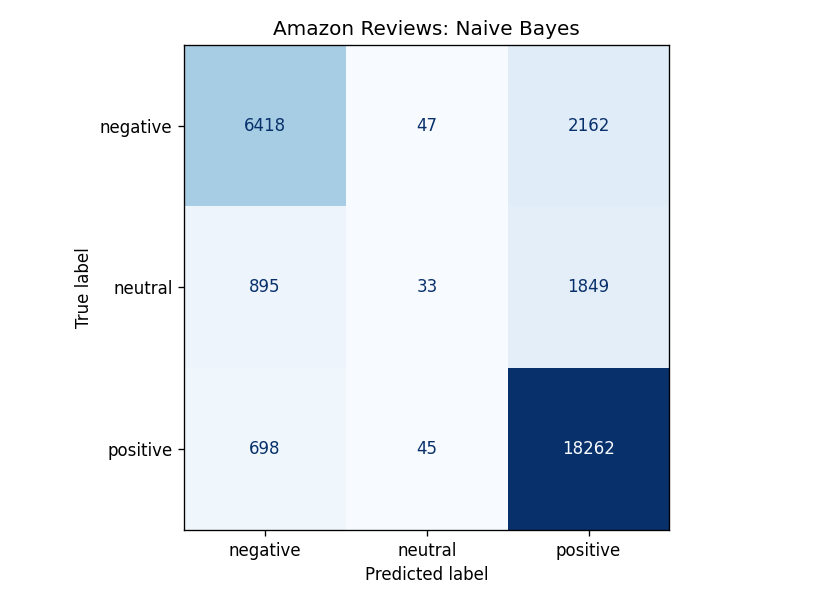

In [15]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

labels = ['negative', 'neutral', 'positive']
cm = confusion_matrix(y_test, y_pred, labels=labels)
print('Confusion matrix: rows = actual, columns = predicted')
print(pd.DataFrame(cm, index=labels, columns=labels))

fig, ax = plt.subplots(figsize=(7, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(ax=ax, cmap='Blues', values_format='d', colorbar=False)
ax.set_title('Amazon Reviews: Naive Bayes')
plt.tight_layout()
plt.show()


### Results
The Naive Bayes model reached 81.27% test accuracy and 0.5597 macro F1. It predicted positive reviews well, but missed most neutral reviews: only 33 out of 2,777 were classified correctly. The classes are imbalanced, so accuracy alone does not show the full result. The confusion matrix and class-level scores show this limitation.